In [96]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [97]:
from sklearn.datasets import make_classification

In [90]:
#create the dataset
x,y=make_classification(n_samples=1000,n_features=10,n_classes=2,random_state=42)

In [91]:
#pd.DataFrame(x)

In [92]:
#train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [93]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("slope or coffeicent:",mae)
print("intercept:",score)

slope or coffeicent: 0.17
intercept: 0.3116712217835813


In [94]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
sc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(sc)
print(cm)
print(cr)

0.83
[[75 14]
 [20 91]]
              precision    recall  f1-score   support

           0       0.79      0.84      0.82        89
           1       0.87      0.82      0.84       111

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200





Hyperparameter Tunning and Cross Validation 



In [95]:
model=LogisticRegression()
#penality=['l1','l2','elasticnet']
#c_values=[100,10,1.0,0.1,0.01]
#solver=['newton-cg','lbfgs','liblinear','sag','saga']

In [89]:
params = [
    {
        'penalty':['l1'],
        'solver':['liblinear','saga'],
        'C':[100,10,1.0,0.1,0.01]
    },
    {
        'penalty':['l2'],
        'solver':['newton-cg','lbfgs','liblinear','sag','saga'],
        'C':[100,10,1.0,0.1,0.01]
    }
]
params

[{'penalty': ['l1'],
  'solver': ['liblinear', 'saga'],
  'C': [100, 10, 1.0, 0.1, 0.01]},
 {'penalty': ['l2'],
  'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
  'C': [100, 10, 1.0, 0.1, 0.01]}]

In [90]:
#Grid Search CV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold(n_splits=5)
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv,n_jobs=-1,error_score='raise')
grid

,estimator,LogisticRegression()
,param_grid,"[{'C': [100, 10, ...], 'penalty': ['l1'], 'solver': ['liblinear', 'saga']}, {'C': [100, 10, ...], 'penalty': ['l2'], 'solver': ['newton-cg', 'lbfgs', ...]}]"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,penalty,'l2'


In [91]:
grid.fit(x_train,y_train)

,estimator,LogisticRegression()
,param_grid,"[{'C': [100, 10, ...], 'penalty': ['l1'], 'solver': ['liblinear', 'saga']}, {'C': [100, 10, ...], 'penalty': ['l2'], 'solver': ['newton-cg', 'lbfgs', ...]}]"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,penalty,'l2'


In [92]:
print(grid.best_score_)

0.8787500000000001


In [93]:
grid.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

Randomized CV

In [94]:
from sklearn.model_selection import RandomizedSearchCV
randomcv=RandomizedSearchCV(estimator=model,param_distributions=params,cv=5,scoring='accuracy')

In [95]:
randomcv.fit(x_train,y_train)

,estimator,LogisticRegression()
,param_distributions,"[{'C': [100, 10, ...], 'penalty': ['l1'], 'solver': ['liblinear', 'saga']}, {'C': [100, 10, ...], 'penalty': ['l2'], 'solver': ['newton-cg', 'lbfgs', ...]}]"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [96]:
randomcv.best_score_

np.float64(0.8787499999999999)

In [97]:
randomcv.best_params_

{'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.01}

In [98]:
y_pred=randomcv.predict(x_test)

In [99]:
sc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(sc)
print(cm)
print(cr)

0.825
[[78 11]
 [24 87]]
              precision    recall  f1-score   support

           0       0.76      0.88      0.82        89
           1       0.89      0.78      0.83       111

    accuracy                           0.82       200
   macro avg       0.83      0.83      0.82       200
weighted avg       0.83      0.82      0.83       200



In [98]:
#logistic regression for multiclass calssification problem
## create a dataset 
x,y=make_classification(n_samples=1000,n_features=10,n_informative=3,random_state=15)


In [99]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [118]:
from sklearn.linear_model import LogisticRegression
ls=LogisticRegression(max_iter=5000,class_weight='balanced')
ls.fit(x_train,y_train)
y_pred=ls.predict(x_test)
x,y

(array([[-0.62138617,  0.6753117 ,  0.90406352, ..., -1.06513582,
         -1.20990406, -0.34949184],
        [ 1.28331307,  0.50062593,  0.17311447, ...,  1.54333476,
         -1.37958299, -1.29351321],
        [ 0.04307305,  0.35122145, -0.24037148, ...,  0.43006839,
         -0.93767071,  1.29103054],
        ...,
        [-0.19607514, -1.77697177, -0.72374413, ..., -0.39068155,
         -1.16244526, -1.38630063],
        [ 1.24214208, -2.10284788,  1.06758851, ...,  0.55784568,
          1.46643337, -1.39343981],
        [-1.15725373, -0.18928327,  0.11574721, ...,  0.22195743,
          1.01922912, -0.30546649]], shape=(1000, 10)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 

In [119]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
a_score=accuracy_score(y_test,y_pred)
c_r=classification_report(y_test,y_pred)
c_m=confusion_matrix(y_test,y_pred)
print(a_score)
print(c_r)
print(c_m)

0.796
              precision    recall  f1-score   support

           0       0.99      0.80      0.89       247
           1       0.02      0.33      0.04         3

    accuracy                           0.80       250
   macro avg       0.51      0.57      0.46       250
weighted avg       0.98      0.80      0.88       250

[[198  49]
 [  2   1]]


 Logestic Regression fro imbalanced Dataset

In [120]:
#generate adn plot synthetic imbalanced classification dataset 
from collections import Counter 
from sklearn.datasets import make_classification


In [121]:
#imbalanced dataset
x,y=make_classification(n_samples=1000,n_features=10,n_classes=2,random_state=10,n_redundant=0,weights=[0.99])

In [122]:
x

array([[-0.62138617,  0.6753117 ,  0.90406352, ..., -1.06513582,
        -1.20990406, -0.34949184],
       [ 1.28331307,  0.50062593,  0.17311447, ...,  1.54333476,
        -1.37958299, -1.29351321],
       [ 0.04307305,  0.35122145, -0.24037148, ...,  0.43006839,
        -0.93767071,  1.29103054],
       ...,
       [-0.19607514, -1.77697177, -0.72374413, ..., -0.39068155,
        -1.16244526, -1.38630063],
       [ 1.24214208, -2.10284788,  1.06758851, ...,  0.55784568,
         1.46643337, -1.39343981],
       [-1.15725373, -0.18928327,  0.11574721, ...,  0.22195743,
         1.01922912, -0.30546649]], shape=(1000, 10))

In [123]:
Counter(y)

Counter({np.int64(0): 983, np.int64(1): 17})

<Axes: xlabel='0', ylabel='1'>

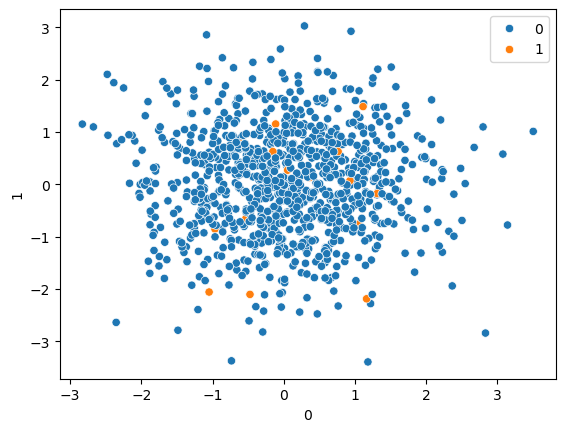

In [124]:
import pandas as pd 
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)

In [125]:
from sklearn.model_selection  import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [126]:
#hyperparameter tuning 
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
penalty=['l1','l2','elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg','lbfgs','liblinear','sag','saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]


In [127]:
params=dict(penalty=penalty,C=c_values,solver=solver,class_weight=class_weight)

In [128]:
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1.0, 0.1, 0.01],
 'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
 'class_weight': [{0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 50},
  {0: 1, 1: 100},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 50},
  {0: 10, 1: 100},
  {0: 50, 1: 1},
  {0: 50, 1: 10},
  {0: 50, 1: 50},
  {0: 50, 1: 100},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 50},
  {0: 100, 1: 100}]}

In [129]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)

In [134]:
grid.fit(x_train,y_train)

C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: T

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [135]:
print(grid.best_score_)

0.9813333333333333


In [136]:
print(grid.best_params_)

{'C': 100, 'class_weight': {0: 50, 1: 1}, 'penalty': 'l1', 'solver': 'liblinear'}
